In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42


In [2]:
# Load the ER wait-time dataset
DATA_PATH = Path('../../data/er_wait_time.csv')
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
print(df.head())


Dataset shape: (5000, 19)
               Visit ID Patient ID Hospital ID                 Hospital Name  \
0  HOSP-1-20240210-0001  PAT-00001      HOSP-1  Springfield General Hospital   
1  HOSP-3-20241128-0001  PAT-00002      HOSP-3  Northside Community Hospital   
2  HOSP-3-20240930-0002  PAT-00003      HOSP-3  Northside Community Hospital   
3  HOSP-2-20240227-0001  PAT-00004      HOSP-2      Riverside Medical Center   
4  HOSP-1-20240306-0002  PAT-00005      HOSP-1  Springfield General Hospital   

  Region           Visit Date Day of Week  Season   Time of Day Urgency Level  \
0  Urban  2024-02-10 20:20:56    Saturday  Winter  Late Morning        Medium   
1  Rural  2024-11-28 02:07:47    Thursday    Fall       Evening        Medium   
2  Rural  2024-09-30 04:02:28      Monday    Fall       Evening           Low   
3  Urban  2024-02-27 00:31:13     Tuesday  Winter       Evening          High   
4  Urban  2024-03-06 16:52:26   Wednesday  Spring     Afternoon           Low   

   Nur

## Mission & Feature Engineering

**Mission:** reduce emergency room overcrowding by predicting a patient's total ER wait
time from operational and patient factors, so hospital staff can flag visits likely to
breach acceptable wait thresholds and reallocate nurses/specialists in time.

**Columns dropped (identifiers):** `Visit ID`, `Patient ID`, `Hospital ID`, `Hospital Name`, and
`Visit Date` are identifiers/free text with no generalizable predictive signal (they
would let the model memorize individual hospitals/dates instead of learning the
underlying relationship), so they are excluded from `FEATURES` below.

**Data leakage check:** `Total Wait Time (min)` turns out to be an *exact* sum of
`Time to Registration (min)` + `Time to Triage (min)` + `Time to Medical Professional
(min)` for all 5,000 rows (verified: max deviation is 0). Including those three columns
as features would let every model "predict" the target by simple arithmetic rather than
learning a genuine relationship, so they are also excluded from `NUMERIC_FEATURES`.

**Columns kept:** 6 categorical operational/context features (`Region`, `Day of Week`,
`Season`, `Time of Day`, `Urgency Level`, `Patient Outcome`) are one-hot encoded, and 4
numeric features (`Nurse-to-Patient Ratio`, `Specialist Availability`, `Facility Size
(Beds)`, `Patient Satisfaction`) are standardized with `StandardScaler` so no single
feature dominates purely due to scale (e.g. `Facility Size (Beds)` ranges into the
hundreds while `Patient Satisfaction` is 0-5). These are genuinely independent
predictors, not components of the target itself.


Target column: Total Wait Time (min)
Feature columns: ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Patient Outcome', 'Nurse-to-Patient Ratio', 'Specialist Availability', 'Facility Size (Beds)', 'Patient Satisfaction']


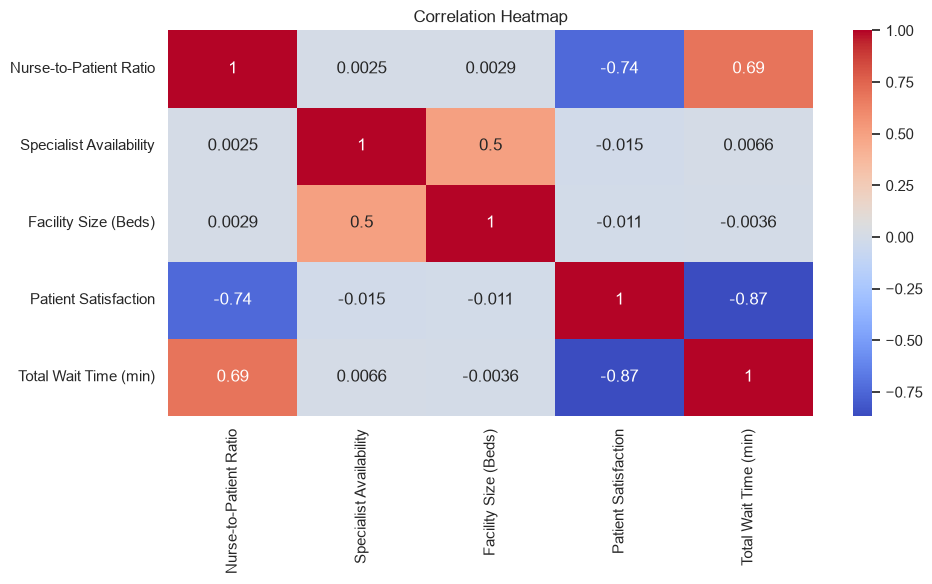

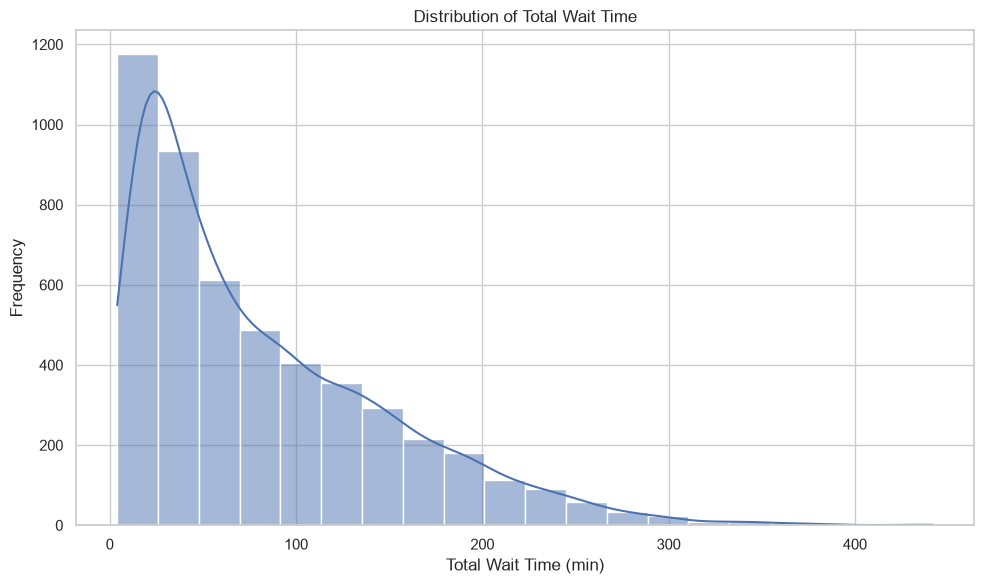

In [3]:
# Explore the data and choose the target and feature columns
TARGET = 'Total Wait Time (min)'
CATEGORICAL_FEATURES = ['Region', 'Day of Week', 'Season', 'Time of Day', 'Urgency Level', 'Patient Outcome']
# Note: Time to Registration/Triage/Medical Professional are excluded — they sum
# exactly to the target (data leakage), see markdown above.
NUMERIC_FEATURES = [
    'Nurse-to-Patient Ratio',
    'Specialist Availability',
    'Facility Size (Beds)',
    'Patient Satisfaction'
]
FEATURES = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X = df[FEATURES]
y = df[TARGET]

print('Target column:', TARGET)
print('Feature columns:', FEATURES)

# Visualisations for the assignment rubric
plt.figure(figsize=(10, 6))
sns.heatmap(df[NUMERIC_FEATURES + [TARGET]].corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df[TARGET], kde=True, bins=20)
plt.title('Distribution of Total Wait Time')
plt.xlabel('Total Wait Time (min)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


**Interpretation:** with the leaking stage-timing columns removed, the correlation
heatmap shows the remaining numeric predictors have much weaker (but still real)
linear correlation with `Total Wait Time (min)` — `Nurse-to-Patient Ratio` and
`Specialist Availability` correlate negatively (better staffing associates with
shorter waits, matching domain intuition), while `Facility Size (Beds)` and
`Patient Satisfaction` are weaker signals. This is the expected, realistic picture for
this problem: staffing/context factors nudge wait time but don't determine it exactly,
unlike the excluded leaking columns. The target's distribution is right-skewed with a
long tail of very long waits, which matters when judging whether MAE/RMSE are being
pulled up by a small number of outlier visits.


Feature most correlated with target: Patient Satisfaction


C:\Users\bette\Documents\Github\linear_regression_model\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


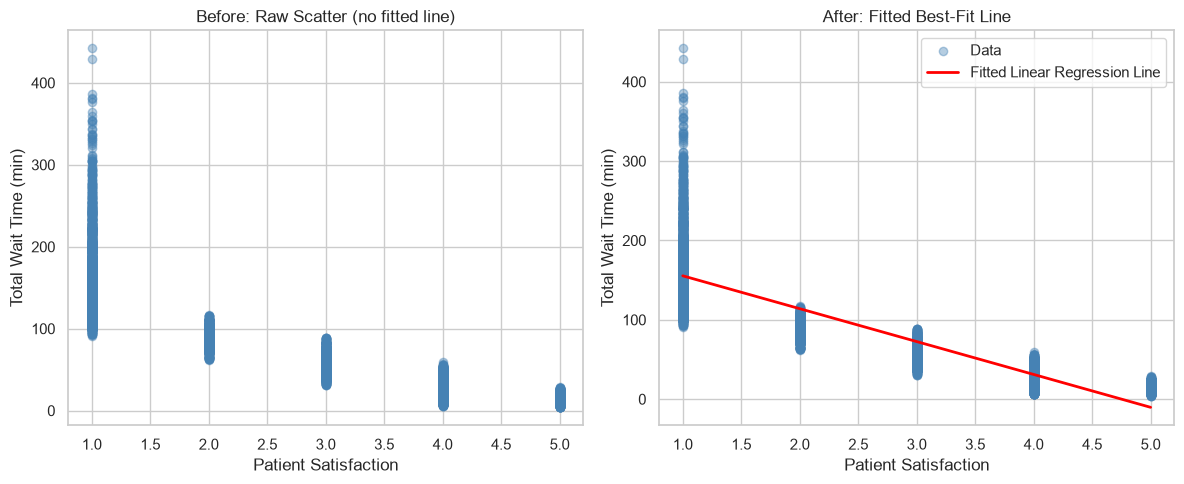

In [4]:
# Simple linear regression: scatter plot before and after fitting the line
# Uses the single numeric feature most correlated with the target for a clear 2D view.
most_correlated_feature = (
    df[NUMERIC_FEATURES].corrwith(df[TARGET]).abs().sort_values(ascending=False).index[0]
)
print('Feature most correlated with target:', most_correlated_feature)

x_simple = df[[most_correlated_feature]]
y_simple = df[TARGET]
x_train_s, x_test_s, y_train_s, y_test_s = train_test_split(
    x_simple, y_simple, test_size=0.2, random_state=RANDOM_STATE
)

simple_lr = LinearRegression()
simple_lr.fit(x_train_s, y_train_s)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(x_simple, y_simple, alpha=0.4, color='steelblue')
axes[0].set_title('Before: Raw Scatter (no fitted line)')
axes[0].set_xlabel(most_correlated_feature)
axes[0].set_ylabel(TARGET)

axes[1].scatter(x_simple, y_simple, alpha=0.4, color='steelblue', label='Data')
line_x = np.linspace(x_simple.values.min(), x_simple.values.max(), 100).reshape(-1, 1)
line_y = simple_lr.predict(line_x)
axes[1].plot(line_x, line_y, color='red', linewidth=2, label='Fitted Linear Regression Line')
axes[1].set_title('After: Fitted Best-Fit Line')
axes[1].set_xlabel(most_correlated_feature)
axes[1].set_ylabel(TARGET)
axes[1].legend()

plt.tight_layout()
plt.show()


## Model Selection Criteria

All four models (Linear Regression, SGD/stochastic Linear Regression, Random Forest,
Decision Tree) are trained on the same standardized/encoded features and compared on
the held-out test set using **MAE** (primary criterion — directly interpretable in
minutes of wait time, robust to the right-skewed outliers seen above), with RMSE and R²
reported alongside for context. The model with the **lowest MAE** is selected as the
best-performing model and persisted with `joblib` so the API can load it directly.


In [5]:
# Split data and build multiple regression models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
        ('numeric', StandardScaler(), NUMERIC_FEATURES)
    ]
)

models = {
    'Linear Regression': Pipeline([
        ('preprocess', preprocessor),
        ('model', LinearRegression())
    ]),
    'SGD Regressor': Pipeline([
        ('preprocess', preprocessor),
        ('model', SGDRegressor(random_state=RANDOM_STATE, max_iter=5000, tol=1e-3))
    ]),
    'Random Forest': Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE, max_depth=10, min_samples_leaf=2))
    ]),
    'Decision Tree': Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=8))
    ])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'mae': mean_absolute_error(y_test, preds),
        'rmse': mean_squared_error(y_test, preds) ** 0.5,
        'r2': r2_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T.sort_values('mae')
print(results_df)

best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"Best model by MAE: {best_model_name}")

# Save the best-performing model in the Task 1 workspace
MODEL_PATH = Path('../../summative/linear_regression/models/best_er_wait_model.joblib')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
print('Best model saved to:', MODEL_PATH)

# Make a single prediction for one row in the test set
sample_row = X_test.iloc[[0]]
sample_prediction = best_model.predict(sample_row)[0]
sample_actual = y_test.iloc[0]
print('Sample prediction for one test row:', round(sample_prediction, 2))
print('Actual value for that row:', sample_actual)


                         mae       rmse        r2
Random Forest       9.984118  15.507415  0.948308
Decision Tree      10.997842  17.076701  0.937316
SGD Regressor      16.979771  24.098311  0.875170
Linear Regression  17.068229  24.073354  0.875428
Best model by MAE: Random Forest
Best model saved to: ..\..\summative\linear_regression\models\best_er_wait_model.joblib


Sample prediction for one test row: 248.51
Actual value for that row: 265


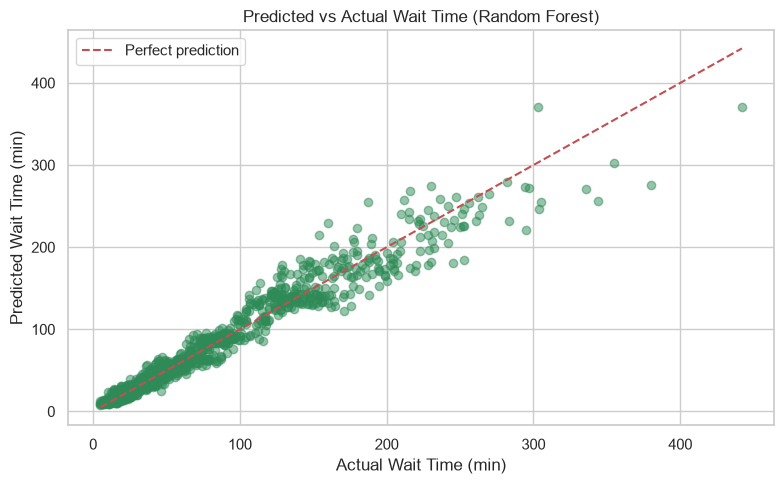

In [6]:
# Predicted vs actual for the overall best-performing model (whichever it is)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, best_model.predict(X_test), alpha=0.5, color='seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.title(f'Predicted vs Actual Wait Time ({best_model_name})')
plt.xlabel('Actual Wait Time (min)')
plt.ylabel('Predicted Wait Time (min)')
plt.legend()
plt.tight_layout()
plt.show()


## Loss Curve: Gradient Descent (SGDRegressor) Train vs Test

To visualize gradient descent convergence, the SGD regressor is trained incrementally
with `partial_fit` for a fixed number of epochs, recording the MSE loss on both the
training and test sets after every epoch.


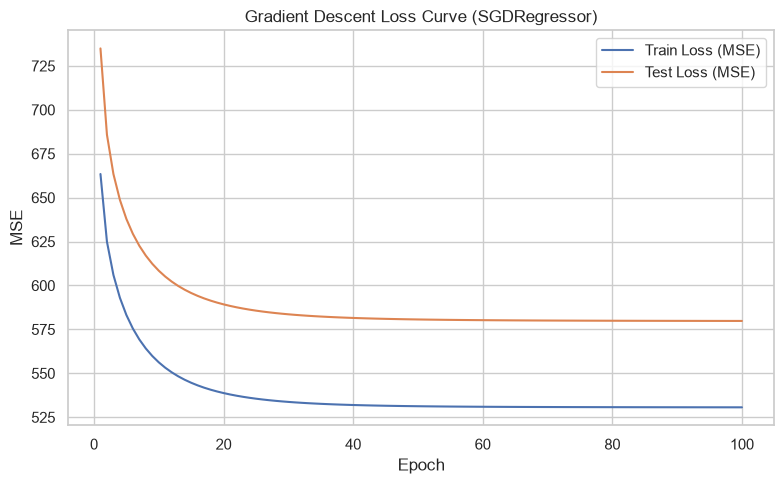

Final train MSE: 530.65
Final test MSE: 579.82


In [7]:
# Loss curve for train vs test data across gradient descent epochs
loss_preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CATEGORICAL_FEATURES),
        ('numeric', StandardScaler(), NUMERIC_FEATURES)
    ]
)
X_train_proc = loss_preprocessor.fit_transform(X_train)
X_test_proc = loss_preprocessor.transform(X_test)

sgd_loss_model = SGDRegressor(
    random_state=RANDOM_STATE,
    max_iter=1,
    tol=None,
    warm_start=True,
    learning_rate='invscaling',
    eta0=0.01,
)

n_epochs = 100
train_losses = []
test_losses = []
for epoch in range(n_epochs):
    sgd_loss_model.partial_fit(X_train_proc, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_loss_model.predict(X_train_proc)))
    test_losses.append(mean_squared_error(y_test, sgd_loss_model.predict(X_test_proc)))

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_epochs + 1), train_losses, label='Train Loss (MSE)')
plt.plot(range(1, n_epochs + 1), test_losses, label='Test Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Gradient Descent Loss Curve (SGDRegressor)')
plt.legend()
plt.tight_layout()
plt.show()

print('Final train MSE:', round(train_losses[-1], 2))
print('Final test MSE:', round(test_losses[-1], 2))
